In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import train_test_split

In [2]:
import os

pwd = os.curdir
save_file = os.path.join(pwd, "Results_Case_Study_Mis")
os.makedirs(save_file, exist_ok=True)
seed=0

dir = os.path.join(save_file, f'seed_{seed}')
os.makedirs(dir, exist_ok=True)

## Generate Data

In [3]:
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from scipy.special import expit as sigmoid
from scipy.special import lambertw

In [4]:
c = 0.05
price_cap = 1.2

In [5]:
pwd = os.curdir
file = os.path.join(pwd, "Dataset", "SND 0987.XLSX")
df = pd.read_excel(file)

In [6]:
selected = ['price', 'female', 'age', 'income', 'university', 'urban', 'tbeincidence', 'summerhouserisk', 'outTBEarea', 'worktickrisk', 'knowledge', 'tickbiteever', 'diseaseexperience', 'healthrisktickbite', 'lowtrustvaccinerec'] + ['lowincome']

In [7]:
# 1. Filter only non-vaccinated individuals and drop rows with missing values in selected features or target
df_nonVaccinated = df[df['tbevaccinated'] == 0].copy()
df_nonVaccinated = df_nonVaccinated.dropna(subset=selected + ['buy'])
df_nonVaccinated = df_nonVaccinated[selected + ['buy']]
df_nonVaccinated['price'] = df_nonVaccinated['price'] / df_nonVaccinated['price'].max()
df_nonVaccinated['age'] = df_nonVaccinated['age'] / df_nonVaccinated['price'].max()
df_nonVaccinated['income'] = df_nonVaccinated['income'] / df_nonVaccinated['income'].max()
df_nonVaccinated['knowledge'] = df_nonVaccinated['knowledge'] / df_nonVaccinated['knowledge'].max()

# 2. Reset index to ensure alignment across feature and label vectors
df_nonVaccinated = df_nonVaccinated.reset_index(drop=True)
print(f'Size of the non-vaccinated dataset (after cleaning): {len(df_nonVaccinated)}')

Size of the non-vaccinated dataset (after cleaning): 1151


In [8]:
df_nonVaccinated

,price,female,age,income,university,urban,tbeincidence,summerhouserisk,outTBEarea,worktickrisk,knowledge,tickbiteever,diseaseexperience,healthrisktickbite,lowtrustvaccinerec,lowincome,buy
0,1.00,1,29.0,0.217391,0,1,0.119904,0,1,0,0.571429,1,0,0,1,0,1.0
1,0.25,1,42.0,0.565217,1,0,0.000000,0,0,0,0.428571,0,0,0,0,0,1.0
2,0.25,1,70.0,0.652174,1,1,0.420207,0,0,0,0.714286,1,1,0,0,0,1.0
3,0.50,0,47.0,0.478261,0,0,0.506784,0,1,0,0.428571,1,0,0,0,0,0.0
4,0.50,0,45.0,0.130435,0,1,6.960622,0,1,0,0.142857,1,0,1,0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1146,0.25,0,40.0,0.478261,1,1,0.000000,0,0,0,1.000000,1,0,0,0,0,0.0
1147,0.25,1,26.0,0.217391,0,0,0.000000,0,0,1,0.571429,0,1,1,0,0,1.0
1148,0.10,0,38.0,0.304348,1,0,1.877590,1,0,1,0.285714,1,0,1,0,0,1.0
1149,0.10,1,19.0,1.000000,0,0,0.185491,0,0,0,0.285714,1,0,0,0,0,1.0


In [9]:
# 3. Define features (X), price (p), and target (Y) from the same aligned DataFrame
X = df_nonVaccinated[selected+['buy']].copy()
p = X.pop('price')
g = X.pop('lowincome')
g = np.asarray(g == 1, dtype=bool)
Y = X.pop('buy')
X = np.concatenate((np.ones((X.shape[0], 1)), np.array(X)[:, :-1]), axis=1)

In [10]:
eps = 1e-12
def objective(params):
    a = params[:n_features]
    b = params[-1]
    linear = X @ a + b * p
    pred = sigmoid(linear)
    loss = -(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))
    l0, l1 = np.mean(loss[~g]), np.mean(loss[g])
    obj = l0 + l1
    return obj

def constraint1(params):
    b = params[-1]
    return -b

n_features = X.shape[1]
x0 = np.zeros(n_features+1)

constraints = [
    {'type': 'ineq', 'fun': constraint1}
]

result = minimize(objective, x0, method='SLSQP',
                  constraints=constraints,
                  options={'disp': False})

a_star = result.x[:n_features]
b_star = result.x[-1]

In [11]:
np.random.seed(seed)
linear = X @ a_star + b_star * p
theta = sigmoid(linear)
Y = np.random.binomial(n=1, p=theta)

In [12]:
X_train, X_test, p_train, p_test, g_train, g_test, Y_train, Y_test = train_test_split(
    X, p, g, Y,
    test_size=0.2,
    random_state=seed
)

In [13]:
data = {}
data['train'] = {'X': X_train, 'p': p_train, 'g': g_train, 'Y': Y_train}
data['test'] = {'X': X_test, 'p': p_test, 'g': g_test, 'Y': Y_test}

# Baseline (No Fairness)

In [14]:
def opt_price(X, b, c):
    p_star = (-1/2) * (1/(X @ b))+c/2
    p_star = np.maximum(p_star, c)
    return p_star

In [15]:
X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']
X_test, p_test, g_test, Y_test = data['test']['X'], data['test']['p'], data['test']['g'], data['test']['Y']
n_features = X.shape[1]

def mean_square_error(b):
    linear = 1 + (X @ b) * p
    return np.mean((linear[g] - Y[g]) ** 2)+ np.mean((linear[~g] - Y[~g]) ** 2)

def constraint_negative_price_elasticity(b):
    return -(X @ b)  # X @ b ≤ 0

def constraint_price_lowerbound(b):
    return 1 + (X @ b) * c  # (p^* >= c)

def constraint_price_cap(b):
    return -1 - (X @ b) * (2*price_cap - c)  # p^* ≤ price_cap

In [16]:
eps = 1e-12
def baseline(data):
    X, p, g, Y = data['train']['X'], data['train']['p'], data['train']['g'], data['train']['Y']
    n_features = X.shape[1]
    
    x0 = np.ones(n_features)

    constraints = [
        {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
        {'type': 'ineq', 'fun': constraint_price_lowerbound},
        {'type': 'ineq', 'fun': constraint_price_cap},
    ]

    result = minimize(mean_square_error, x0, method='SLSQP',
                      constraints=constraints,
                      options={'disp': False, 'maxiter': 5000},)

    b_hat = result.x

    l2_diff = np.linalg.norm(b_star - b_hat)     # Euclidean distance
    print("L2 norm difference (b):", l2_diff)

    p_star = opt_price(X, b_hat, c)
    d_star = (1 + (X @ b_hat) * p_star).clip(0,1)

    p1_avg = np.mean(p_star[g])
    p0_avg = np.mean(p_star[~g])
    price_gap = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g])
    d0_avg = np.mean(d_star[~g])
    demand_gap = np.abs(d1_avg - d0_avg)

    print('Average Price:', p1_avg, p0_avg)
    print("Price Difference:", price_gap)
    print('Average Demand:', d1_avg, d0_avg)
    print("Demand Difference:", demand_gap)
    
    #################################
    X_test, g_test = data['test']['X'], data['test']['g']
    p_star = opt_price(X_test, b_hat, c)
    d_star = (1 + (X_test @ b_hat) * p_star).clip(0,1)

    p1_avg = np.mean(p_star[g_test])
    p0_avg = np.mean(p_star[~g_test])
    price_gap_test = np.abs(p1_avg - p0_avg)

    d1_avg = np.mean(d_star[g_test])
    d0_avg = np.mean(d_star[~g_test])
    demand_gap_test = np.abs(d1_avg - d0_avg)

    return b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test

In [17]:
b_hat, price_gap, demand_gap, price_gap_test, demand_gap_test = baseline(data)

L2 norm difference (b): 6.2231466519969
Average Price: 0.5371503716272262 0.6145729236304208
Price Difference: 0.07742255200319459
Average Demand: 0.47451791618015393 0.4775790553706592
Demand Difference: 0.0030611391905052687


In [18]:
price_gap_test

0.09049401143674662

# Tools

In [19]:
def metrics(X, a_star, b_star, p_star, c):
    _d = sigmoid(X @ a_star + b_star * p_star)
    r = sum((p_star-c) * _d)
    z = X @ a_star + b_star * p_star  # shape: (n,)
    s = (-1.0 / b_star) * np.sum(np.logaddexp(0.0, z))
    return _d, r, s

# ML Fairness

In [20]:
pred_hat = (1 + (X @ b_hat) * p)
mse_gap = np.abs(np.mean((Y[~g] - pred_hat[~g]) ** 2)-np.mean((Y[g] - pred_hat[g]) ** 2))

alpha_list = []
rev_ML_test, sur_ML_test = [], []

p0_set, p1_set = [], []
d0_set, d1_set = [], []

x0 = np.ones(n_features)
for alpha in np.linspace(0,1,6):
    alpha_list.append(alpha)
    print('alpha', alpha)
    def constraint_ML1(b):
        pred = 1 + (X @ b) * p

        mse0 = np.mean((Y[~g] - pred[~g]) ** 2)
        mse1 = np.mean((Y[g] - pred[g]) ** 2)
        return (1-alpha) * (mse_gap) - mse1 + mse0

    def constraint_ML2(b):
        pred = 1 + (X @ b) * p

        mse0 = np.mean((Y[~g] - pred[~g]) ** 2)
        mse1 = np.mean((Y[g] - pred[g]) ** 2)
        return (1-alpha) * (mse_gap) + mse1 - mse0

    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_ML1},
            {'type': 'ineq', 'fun': constraint_ML2}
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        #options={'maxiter': 5000, 'ftol': 1e-13, 'eps': 1e-9, 'disp': False}
    )

    b_val = result.x

    #############################Test#####################################
    p_star_test = opt_price(X_test, b_val, c)

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    p0_star_test, p1_star_test = np.mean(p_star_test[~g_test]), np.mean(p_star_test[g_test])

    p0_set.append(p_star_test[~g_test])
    p1_set.append(p_star_test[g_test])

    d0_set.append(d_test[~g_test])
    d1_set.append(d_test[g_test])

    rev_ML_test.append(r_test)
    sur_ML_test.append(s_test)

    pred = 1 + (X_test @ b_val) * p_test

    x0 = b_val

alpha 0.0
alpha 0.2
alpha 0.4
alpha 0.6000000000000001
alpha 0.8
alpha 1.0


In [21]:
import os
fontsize = 24
my_labels = [f'{a:.1f}' for a in alpha_list]

def plot_default_boxplot(data_set, filename=None, y_limits=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(data_set, labels=my_labels, patch_artist=True,
               boxprops=dict(facecolor='#addd8e', color='black', alpha=0.7),
               medianprops=dict(color='black', linewidth=3))

    if y_limits:
        ax.set_ylim(y_limits)

    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    plt.tight_layout()

    if filename:
        plt.savefig(filename, bbox_inches="tight")
        print(f"Plot saved as: {filename}")

    plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_grouped_boxplot(set0, set1, filename=None, y_limits=None, mean_plot=False, price=True, alpha_list=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    """
    Plots grouped boxplots. Since markers cannot have hatches in Matplotlib,
    outliers are filled with colors matching the boxes to ensure visual consistency.
    """
    my_labels = [f'{a:.1f}' for a in alpha_list]

    fig, ax = plt.subplots(figsize=(12, 8))
    positions = np.arange(len(my_labels)) * 2.0
    width = 0.6

    flier0 = dict(marker='o', markerfacecolor='#1f78b4', markeredgecolor='black',
                  markersize=6, alpha=1)
    flier1 = dict(marker='o', markerfacecolor='#fdbf6f', markeredgecolor='black',
                  markersize=6, alpha=0.7)

    # --- 2. Generate Boxplots ---
    box0 = ax.boxplot(set0, positions=positions - width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier0)

    box1 = ax.boxplot(set1, positions=positions + width/2, widths=width,
                      patch_artist=True, manage_ticks=False,
                      showmeans=mean_plot, meanline=True, flierprops=flier1)

    # --- 3. Style Box Bodies (Applying Patterns) ---
    for b0 in box0['boxes']:
        b0.set(facecolor='#1f78b4', alpha=0.7, edgecolor='black')
    for b1 in box1['boxes']:
        b1.set(facecolor='#fdbf6f', alpha=0.7, edgecolor='black')

    # --- 4. Style Mean Lines ---
    for median in box0['medians'] + box1['medians']:
        median.set(color='black', linewidth=5, linestyle='-')

    # --- 5. Style Median Lines ---
    if mean_plot:
        for mean in box0['means'] + box1['means']:
            mean.set(color='red', linewidth=5, linestyle=(0, (2, 1)))

    # --- 6. Formatting Axes ---
    ax.set_xticks(positions)
    ax.set_xticklabels(my_labels)
    ax.tick_params(axis='both', labelsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=36)

    if y_limits:
        ax.set_ylim(y_limits)

    # --- 7. Legend Configuration ---
    if price == True:
        label0, label1 = '$p_0$', '$p_1$'
    else:
        label0, label1 = '$d_0$', '$d_1$'

    legend_elements = [
        Patch(facecolor='#1f78b4', edgecolor='black', label=label0, alpha=0.7), #hatch='//'
        Patch(facecolor='#fdbf6f', edgecolor='black', label=label1, alpha=0.7), #hatch='\\\\'
    ]

    if mean_plot:
        legend_elements.insert(2, Line2D([0], [0], color='red', lw=5, ls=(0, (2, 1)), label='Mean'))

    ax.legend(handles=legend_elements, fontsize=28, loc='lower center',
              bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=True)

    # Padding for the legend outside the axis
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if filename:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()

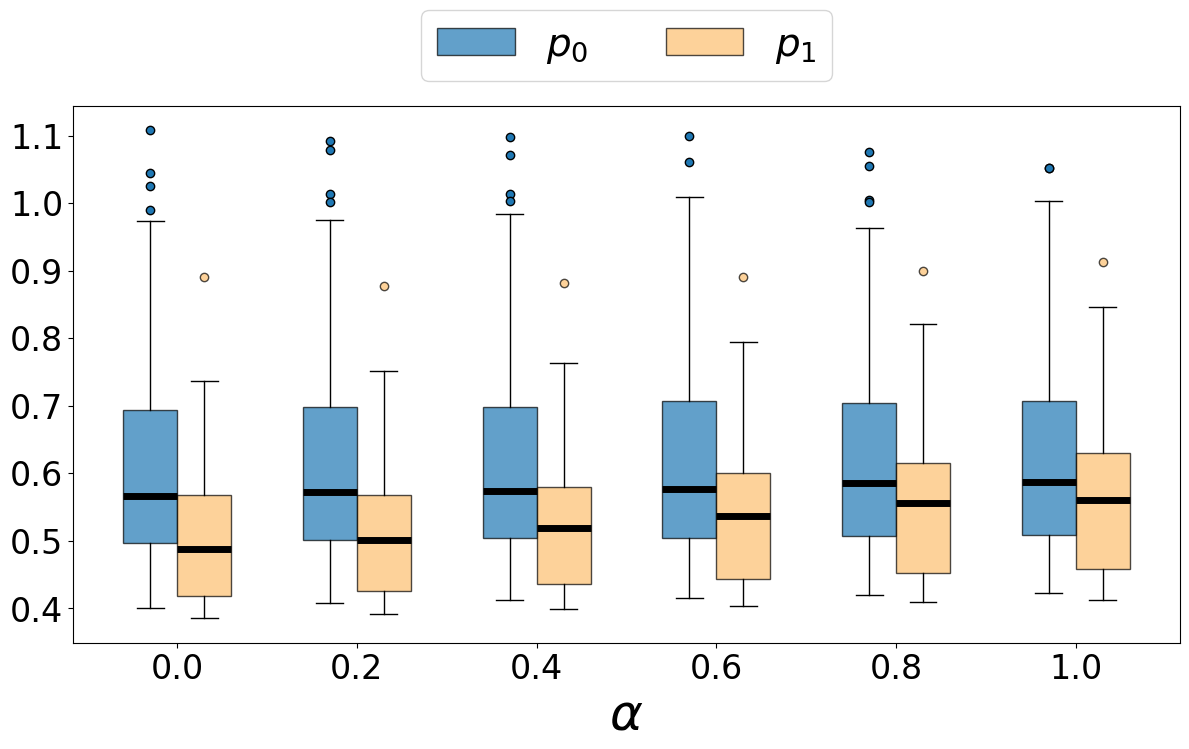

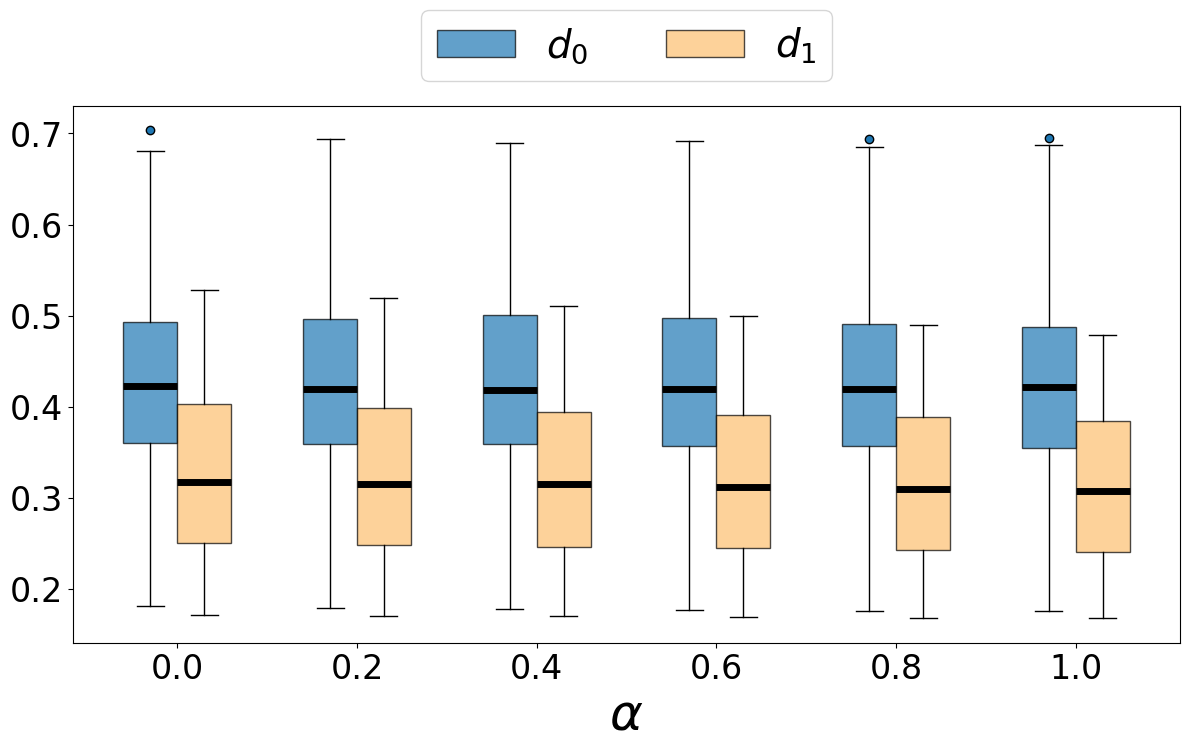

In [23]:
plot_grouped_boxplot(p0_set, p1_set, filename=os.path.join(dir, f"ML_Test_Price.pdf"), price=True, alpha_list=alpha_list)
plot_grouped_boxplot(d0_set, d1_set, filename=os.path.join(dir, f"ML_Test_Demand.pdf"), price=False, alpha_list=alpha_list)

In [24]:
wel_ML_test = [rev_ML_test[i] + sur_ML_test[i] for i in range(len(rev_ML_test))]

In [25]:
def normalize_to_percentage(data_list):
    base_value = data_list[0]
    return [(val / base_value) * 100 for val in data_list]

rev_norm = normalize_to_percentage(rev_ML_test)
sur_norm = normalize_to_percentage(sur_ML_test)
wel_norm = normalize_to_percentage(wel_ML_test)

target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
indices = [target_alphas.index(a) for a in target_alphas]

info = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(info).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)


Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0  100.65  100.99  101.24  101.45  101.65
S(α)/S(0)  100.0   99.16   98.69   98.35   98.07   97.76
W(α)/W(0)  100.0   99.78   99.64   99.55   99.47   99.37
--------------------------------------------------


# Rawlsian Price Fairness

In [26]:
rev_feo_test, sur_feo_test = [], []
p_feo_test = []

beta_bar = max(opt_price(X, b_hat, c))
beta_under_bar = min(opt_price(X, b_hat, c))
beta_list = []
for beta in np.linspace(0,1,6):
    beta_list.append(beta)

    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar
    
    def constraint_rawlsian_price(b):
        return -2 * (X @ b) * true_beta -1 + c * (X @ b) # p^* ≤ true_beta
    
    x0 = np.ones(n_features)
    
    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_rawlsian_price},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )

    b_val = result.x

    #############################Test#####################################
    if np.abs(X @ b_val).min() > 1e-6:
        p_star_test = opt_price(X_test, b_val, c)
    else:
        p_star_test = np.full(X_test.shape[0], true_beta)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    p_feo_test.append(p_star_test)
    
    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

In [27]:
p_efo_test = []
rev_efo_test, sur_efo_test = [], []

for beta in beta_list:
    true_beta = (1-beta) * (beta_bar) + beta * beta_under_bar

    p_star_test = np.maximum(np.minimum(-1/2 * (1)/(X_test @ b_hat) + c/2, true_beta), c)
    p_efo_test.append(p_star_test)
    
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    rev_efo_test.append(r_test)
    sur_efo_test.append(s_test)

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_Price_FEO.pdf


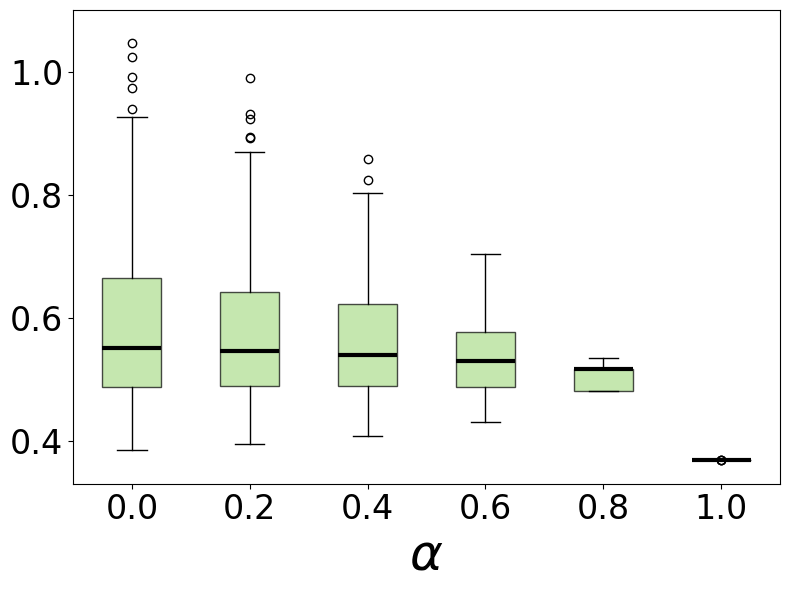

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_Price_EFO.pdf


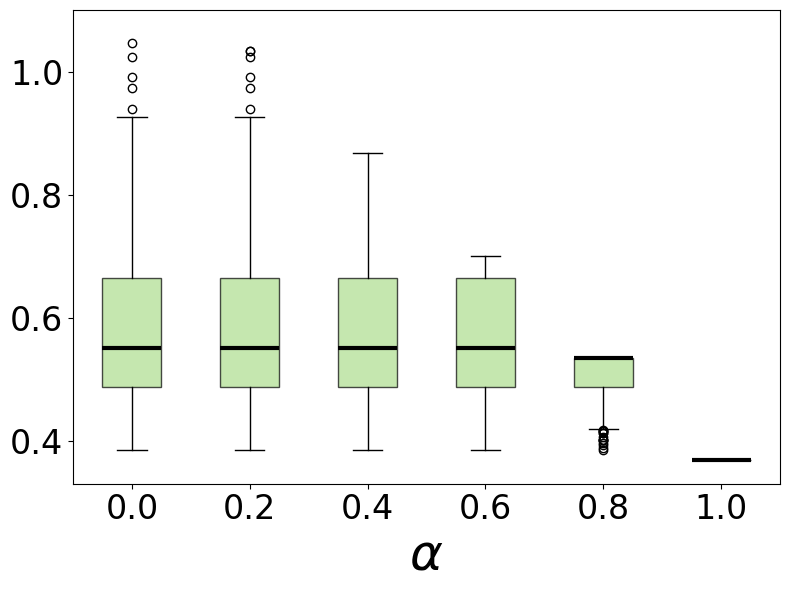

In [30]:
plot_default_boxplot(p_feo_test, filename=os.path.join(dir, f"Rawlsian_Price_FEO.pdf"), y_limits=[0.33, 1.1])
plot_default_boxplot(p_efo_test, filename=os.path.join(dir, f"Rawlsian_Price_EFO.pdf"), y_limits=[0.33, 1.1])

In [31]:
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

info = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(info).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)
target_alphas

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   98.59   96.54   93.30   87.60   67.65
S(α)/S(0)  100.0  102.22  105.05  108.96  115.11  135.26
W(α)/W(0)  100.0  100.72  101.53  102.48  103.73  107.30
--------------------------------------------------


[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

In [32]:
wel_efo_test = [rev_efo_test[i] + sur_efo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_efo_test)
sur_norm = normalize_to_percentage(sur_efo_test)
wel_norm = normalize_to_percentage(wel_efo_test)

info = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(info).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.98   99.54   97.02   88.53   67.65
S(α)/S(0)  100.0  100.06  100.86  104.42  114.25  135.26
W(α)/W(0)  100.0  100.03  100.31  101.36  103.61  107.30
--------------------------------------------------


# Rawlsian Demand Fairness

In [33]:
beta_list = []

rev_feo_test, sur_feo_test = [], []
d_feo_ex_ante = []
d_feo_ex_post = []

p_hat = opt_price(data['train']['X'], b_hat, c)
d_hat = (1 + (data['train']['X'] @ b_hat) * p_hat).clip(0,1)
beta_under_bar = min(d_hat)
beta_bar = 0.5 #max(d_hat)

x0 = np.ones(n_features)
for beta in np.linspace(0, 1, 6):
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar

    def constraint_rawlsian_demand(b):
        return -((1-true_beta) * (1) + c/2 * (X @ b_hat)) * (X @ b) + 0.5 * (X @ b_hat) # d^* ≥ true_beta

    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_rawlsian_demand},
        ]

    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )

    b_val = result.x

    beta_list.append(beta)

    #############################Test#####################################

    p_star_test = opt_price(X_test, b_val, c)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = (1 + (X_test @ b_hat) * p_star_test).clip(0,1)

    d_feo_ex_ante.append(_d_test)
    d_feo_ex_post.append(d_test)

    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

    x0 = b_val

In [34]:
d_efo_ex_ante = []
d_efo_ex_post = []

rev_efo_test, sur_efo_test = [], []

for beta in beta_list:
    true_beta = (1-beta) * beta_under_bar + beta * beta_bar

    d_star_test = np.maximum(1/2 + c * (X_test @ b_hat)/(2), true_beta)
    d_efo_ex_ante.append(d_star_test)

    p_star_test=np.maximum((d_star_test - 1)/(X_test @ b_hat),c)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    d_efo_ex_post.append(d_test)
    rev_efo_test.append(r_test)
    sur_efo_test.append(s_test)

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_ExAnte_Demand_FEO.pdf


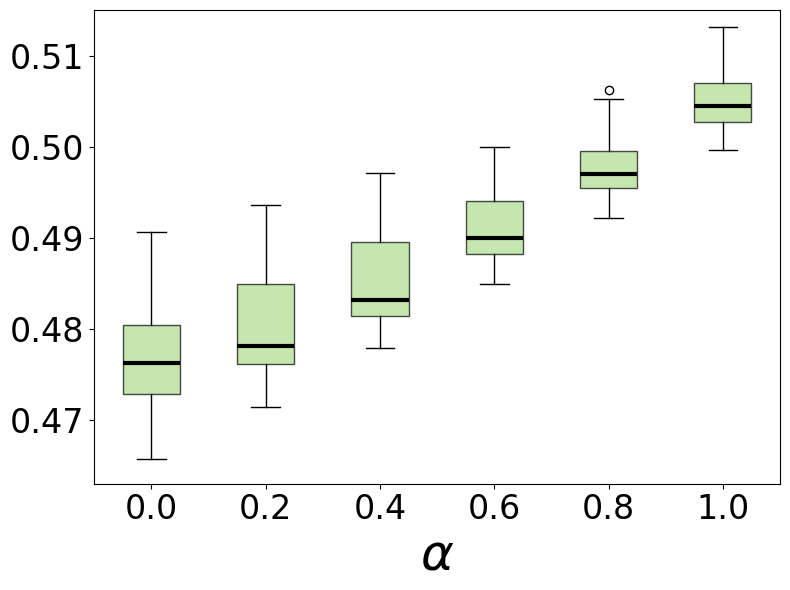

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_ExAnte_Demand_EFO.pdf


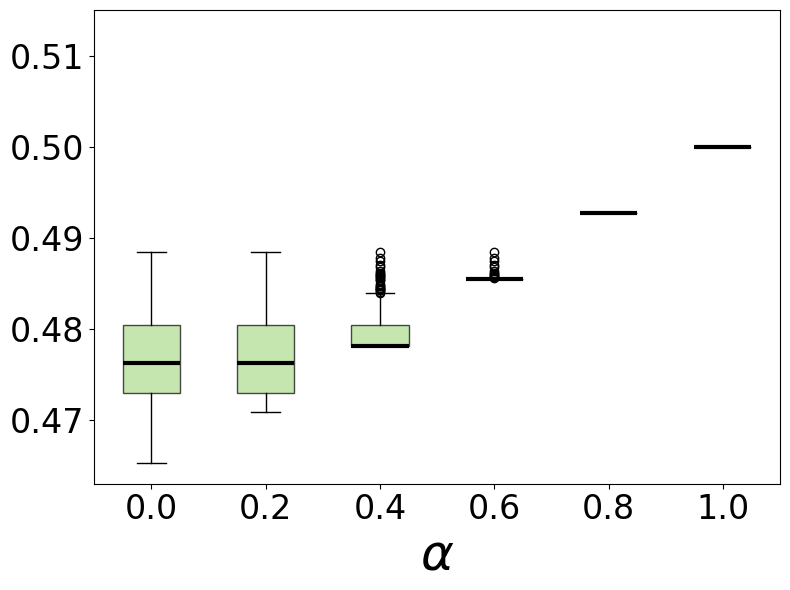

In [35]:
plot_default_boxplot(d_feo_ex_ante, filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_FEO.pdf"), y_limits=[0.463, 0.515])
plot_default_boxplot(d_efo_ex_ante, filename=os.path.join(dir, f"Rawlsian_ExAnte_Demand_EFO.pdf"), y_limits=[0.463, 0.515])

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_ExPost_Demand_FEO.pdf


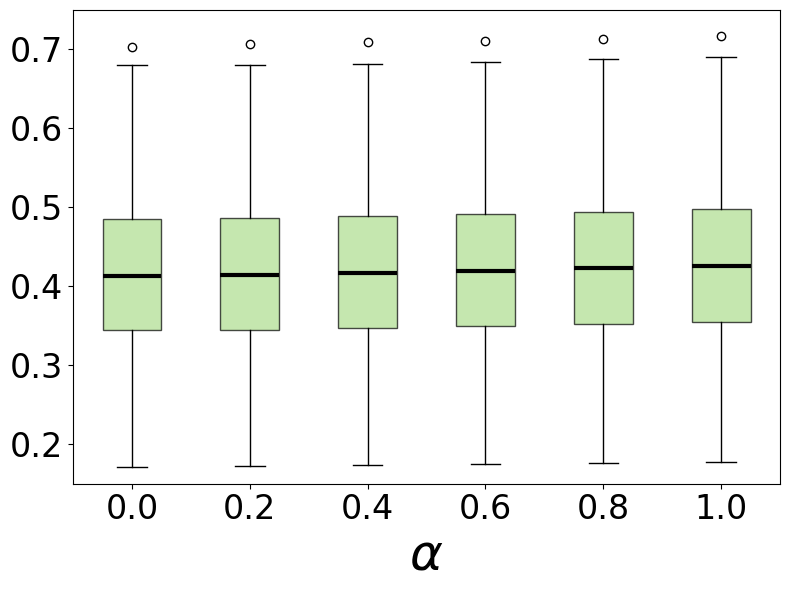

Plot saved as: ./Results_Case_Study_Mis/seed_0/Rawlsian_ExPost_Demand_EFO.pdf


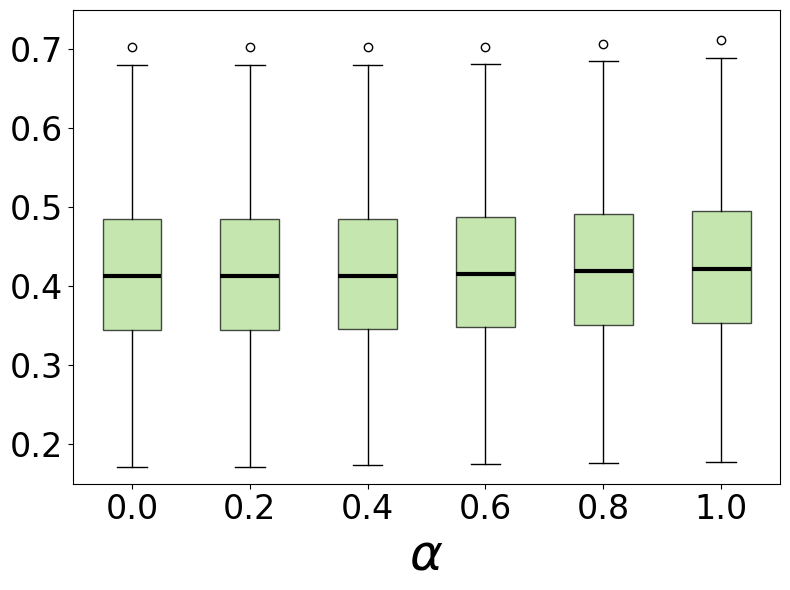

In [36]:
plot_default_boxplot(d_feo_ex_post, filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_FEO.pdf"), y_limits=[0.15, 0.75])
plot_default_boxplot(d_efo_ex_post, filename=os.path.join(dir, f"Rawlsian_ExPost_Demand_EFO.pdf"), y_limits=[0.15, 0.75])

In [37]:
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.66   99.17   98.63   97.93   97.14
S(α)/S(0)  100.0  100.50  101.19  101.94  102.90  104.00
W(α)/W(0)  100.0  100.15  100.35  100.57  100.84  101.16
--------------------------------------------------


In [38]:
wel_efo_test = [rev_efo_test[i] + sur_efo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_efo_test)
sur_norm = normalize_to_percentage(sur_efo_test)
wel_norm = normalize_to_percentage(wel_efo_test)

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.98   99.80   99.26   98.52   97.74
S(α)/S(0)  100.0  100.02  100.26  100.98  102.04  103.14
W(α)/W(0)  100.0  100.01  100.07  100.27  100.59  100.91
--------------------------------------------------


# Parity-wise Price Fairness

In [39]:
alpha_list = []
rev_feo_test, sur_feo_test = [], []
p0_feo_set, p1_feo_set = [], []

x0 = b_hat
for alpha in np.linspace(0,0.99,6):
    def constraint_parity1_price(b):
        p1=np.mean(opt_price(X[g], b, c))
        p0=np.mean(opt_price(X[~g], b, c))
        return (1-alpha) * price_gap - p1 + p0
    
    def constraint_parity2_price(b):
        p1=np.mean(opt_price(X[g], b, c))
        p0=np.mean(opt_price(X[~g], b, c))
        return (1-alpha) * price_gap + p1 - p0

    constraints = [
            {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
            {'type': 'ineq', 'fun': constraint_price_lowerbound},
            {'type': 'ineq', 'fun': constraint_price_cap},
            {'type': 'ineq', 'fun': constraint_parity1_price},
            {'type': 'ineq', 'fun': constraint_parity2_price},
        ]
    
    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )


    b_val = result.x
    
    #############################Test#####################################
    p_star_test = opt_price(X_test, b_val, c)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    
    p_feo_test.append(p_star_test)
    p0_feo_set.append(p_star_test[~g_test])
    p1_feo_set.append(p_star_test[g_test])
    
    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

    alpha_list.append(alpha)

    x0 = b_val

In [40]:
p0_efo_set, p1_efo_set = [], []
rev_efo_test, sur_efo_test = [], []
alpha_list = []

for alpha in np.linspace(0,0.99,6):

    def negative_revenue_test(p):
        p = np.asarray(p)
        term2 = (X_test @ b_hat) * p
        total = np.dot(p-c, 1+term2)
        return -np.sum(total)
    
    def constraint1_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap_test - (p1 - p0)

    def constraint2_test(p):
        p0, p1 = np.mean(p[~g_test]), np.mean(p[g_test])
        return (1 - alpha) * price_gap_test - (p0 - p1)

    def constraint3_test(p):
        return p - c

    def constraint4_test(p):
        return price_cap - p
    
    x0 = np.ones(X_test.shape[0]) * c
    constraints = [
        {'type': 'ineq', 'fun': constraint1_test},
        {'type': 'ineq', 'fun': constraint2_test},
        {'type': 'ineq', 'fun': constraint3_test},
        {'type': 'ineq', 'fun': constraint4_test}
    ]
    
    result = minimize(
        fun=negative_revenue_test,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )
    
    p_star_test = result.x
    p0_efo_set.append(p_star_test[~g_test])
    p1_efo_set.append(p_star_test[g_test])
    
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    rev_efo_test.append(r_test)
    sur_efo_test.append(s_test)

    alpha_list.append(alpha)

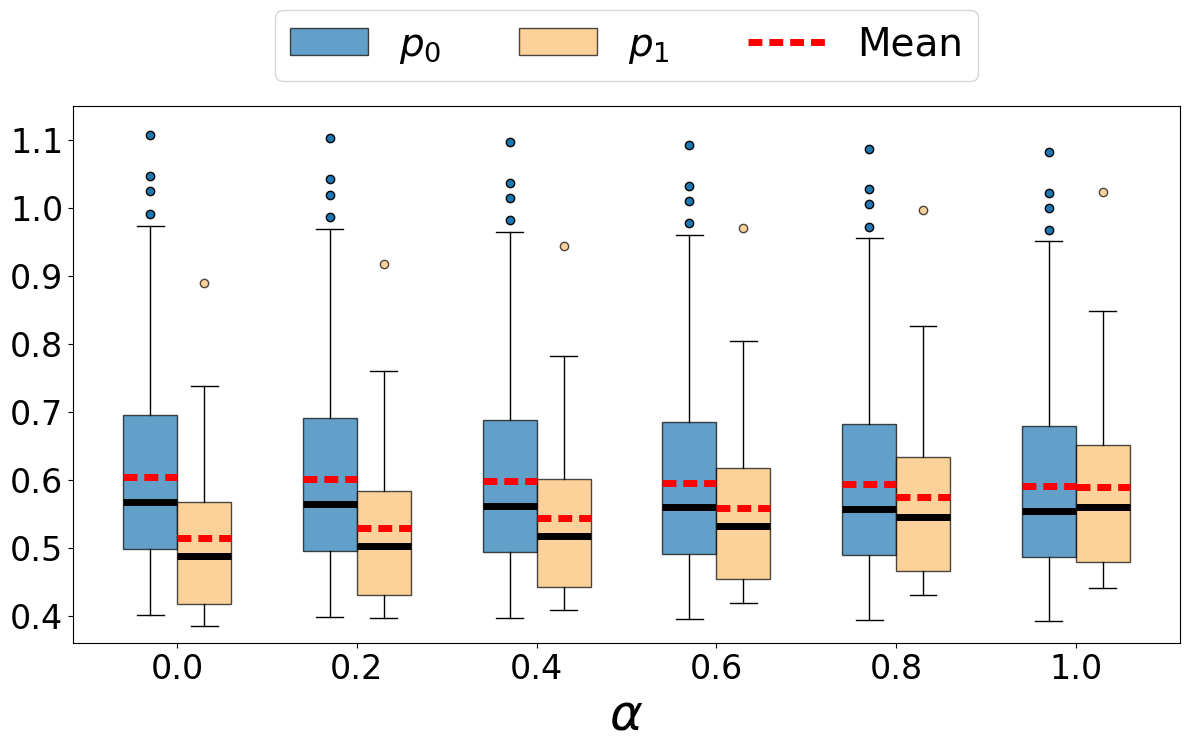

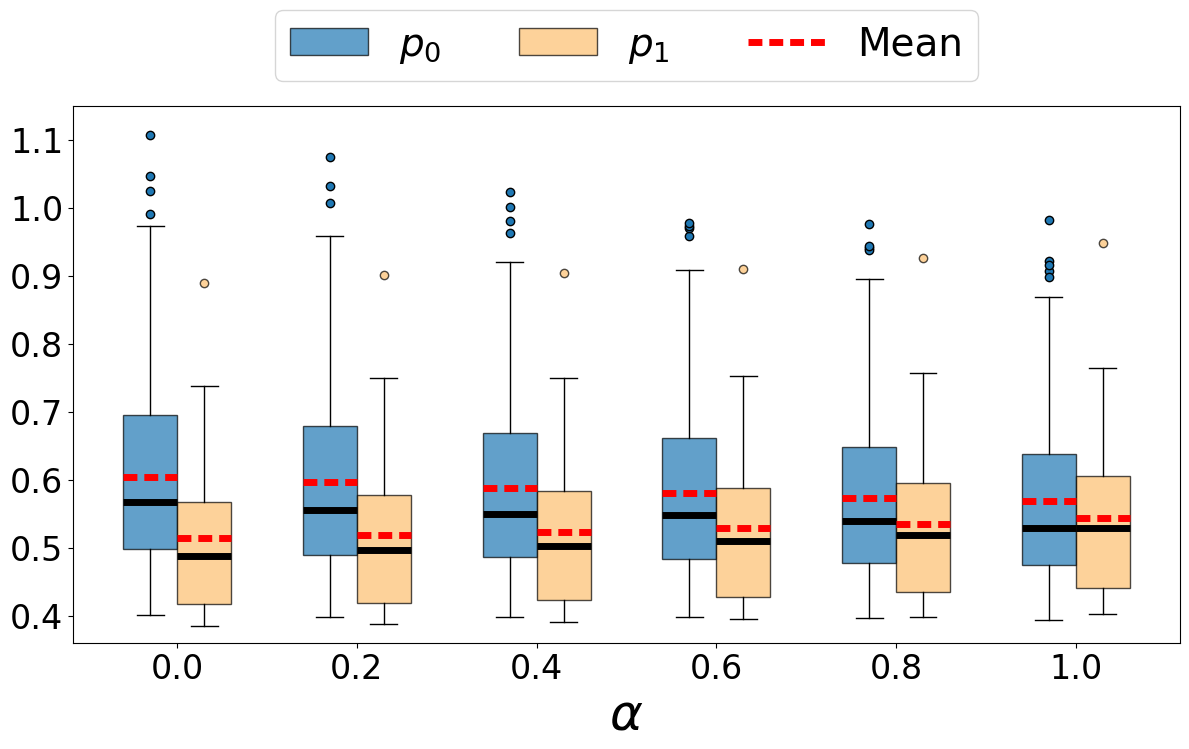

In [42]:
plot_grouped_boxplot(p0_efo_set, p1_efo_set, mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_EFO.pdf"), y_limits=[0.36, 1.15])
plot_grouped_boxplot(p0_feo_set, p1_feo_set, mean_plot=True, filename=os.path.join(dir, f"Parity_Price_Test_FEO.pdf"), y_limits=[0.36, 1.15])

In [43]:
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.25   98.46   97.69   97.00   96.42
S(α)/S(0)  100.0  100.98  102.08  103.07  103.93  104.57
W(α)/W(0)  100.0  100.27  100.58  100.85  101.06  101.20
--------------------------------------------------


In [44]:
wel_efo_test = [rev_efo_test[i] + sur_efo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_efo_test)
sur_norm = normalize_to_percentage(sur_efo_test)
wel_norm = normalize_to_percentage(wel_efo_test)

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0   99.92   99.83   99.73   99.62   99.50
S(α)/S(0)  100.0  100.11  100.23  100.35  100.47  100.60
W(α)/W(0)  100.0  100.03  100.07  100.09  100.12  100.15
--------------------------------------------------


# Parity-wise Demand Fairness

In [45]:
alpha_list = []

rev_feo_test, sur_feo_test = [], []

d0_feo_ex_ante, d1_feo_ex_ante = [], []
d0_feo_ex_post, d1_feo_ex_post = [], []

x0 = b_hat
for alpha in np.linspace(0,1,6):
    def constraint_parity1_demand(b):
        g1 = np.mean(1+((X[g] @ b_hat)*(-0.5/(X[g] @ b + eps)+c/2)))
        g0 = np.mean(1+((X[~g] @ b_hat)*(-0.5/(X[~g] @ b + eps)+c/2)))
        return (1-alpha) * demand_gap - g1 + g0
    
    def constraint_parity2_demand(b):
        g1 = np.mean(1+((X[g] @ b_hat)*(-0.5/(X[g] @ b + eps)+c/2)))
        g0 = np.mean(1+((X[~g] @ b_hat)*(-0.5/(X[~g] @ b + eps)+c/2)))
        return (1-alpha) * demand_gap + g1 - g0

    if alpha != 0:
        constraints = [
                {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
                {'type': 'ineq', 'fun': constraint_price_lowerbound},
                {'type': 'ineq', 'fun': constraint_price_cap},
                {'type': 'ineq', 'fun': constraint_parity1_demand},
                {'type': 'ineq', 'fun': constraint_parity2_demand}
            ]
    else:
        constraints = [
                {'type': 'ineq', 'fun': constraint_negative_price_elasticity},
                {'type': 'ineq', 'fun': constraint_price_lowerbound},
                {'type': 'ineq', 'fun': constraint_price_cap}
            ]

    result = minimize(
        fun=mean_square_error,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': False}
    )

    b_val = result.x
    
    #############################Test#####################################

    p_star_test = opt_price(X_test, b_val, c)
    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = (1 + (X_test @ b_hat) * p_star_test).clip(0,1)

    d0_feo_ex_ante.append(_d_test[~g_test])
    d1_feo_ex_ante.append(_d_test[g_test])
    d0_feo_ex_post.append(d_test[~g_test])
    d1_feo_ex_post.append(d_test[g_test])

    rev_feo_test.append(r_test)
    sur_feo_test.append(s_test)

    alpha_list.append(alpha)

    x0 = b_val

In [46]:
rev_efo_test, sur_efo_test = [], []

d0_efo_ex_ante, d1_efo_ex_ante = [], []
d0_efo_ex_post, d1_efo_ex_post = [], []

for alpha in np.linspace(0,1,6):

    def constraint1_test(p):
        d0_test = np.mean(1 + (X_test[~g_test] @ b_hat) * p[~g_test])
        d1_test = np.mean(1 + (X_test[g_test] @ b_hat) * p[g_test])
        return (1 - alpha) * demand_gap_test - (d1_test - d0_test)

    def constraint2_test(p):
        d0_test = np.mean(1 + (X_test[~g_test] @ b_hat) * p[~g_test])
        d1_test = np.mean(1 + (X_test[g_test] @ b_hat) * p[g_test])
        return (1 - alpha) * demand_gap_test - (d0_test - d1_test)

    if alpha != 0:
        constraints = [
            {'type': 'ineq', 'fun': constraint1_test},
            {'type': 'ineq', 'fun': constraint2_test},
            {'type': 'ineq', 'fun': constraint3_test},
            {'type': 'ineq', 'fun': constraint4_test}
        ]
    else:
        constraints = [
            {'type': 'ineq', 'fun': constraint3_test},
            {'type': 'ineq', 'fun': constraint4_test}
        ]

    x0 = np.ones(X_test.shape[0]) * c
    result = minimize(
        fun=negative_revenue_test,
        x0=x0,
        method='SLSQP',
        constraints=constraints,
        options={'maxiter': 5000, 'disp': True}
    )
    
    p_star_test = result.x

    d_test, r_test, s_test = metrics(X_test, a_star, b_star, p_star_test, c)
    _d_test = (1 + (X_test @ b_hat) * p_star_test).clip(0,1)

    d0_efo_ex_ante.append(_d_test[~g_test])
    d1_efo_ex_ante.append(_d_test[g_test])
    d0_efo_ex_post.append(d_test[~g_test])
    d1_efo_ex_post.append(d_test[g_test])

    rev_efo_test.append(r_test)
    sur_efo_test.append(s_test)

    x0 = p_star_test

Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.82973037910601
            Iterations: 12
            Function evaluations: 2787
            Gradient evaluations: 12
Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.829714168645225
            Iterations: 11
            Function evaluations: 2555
            Gradient evaluations: 11
Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.82966726511346
            Iterations: 11
            Function evaluations: 2556
            Gradient evaluations: 11
Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.829588338527465
            Iterations: 11
            Function evaluations: 2556
            Gradient evaluations: 11
Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.82947784169532
            Iterations: 11
            Fu

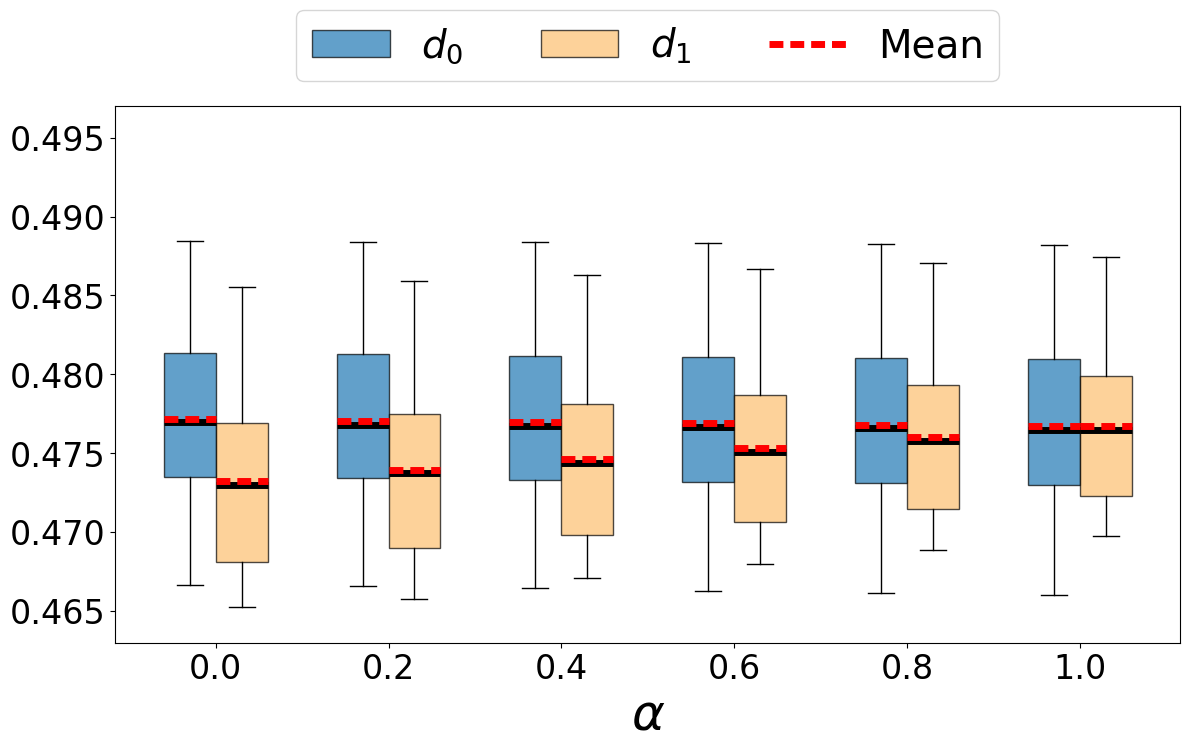

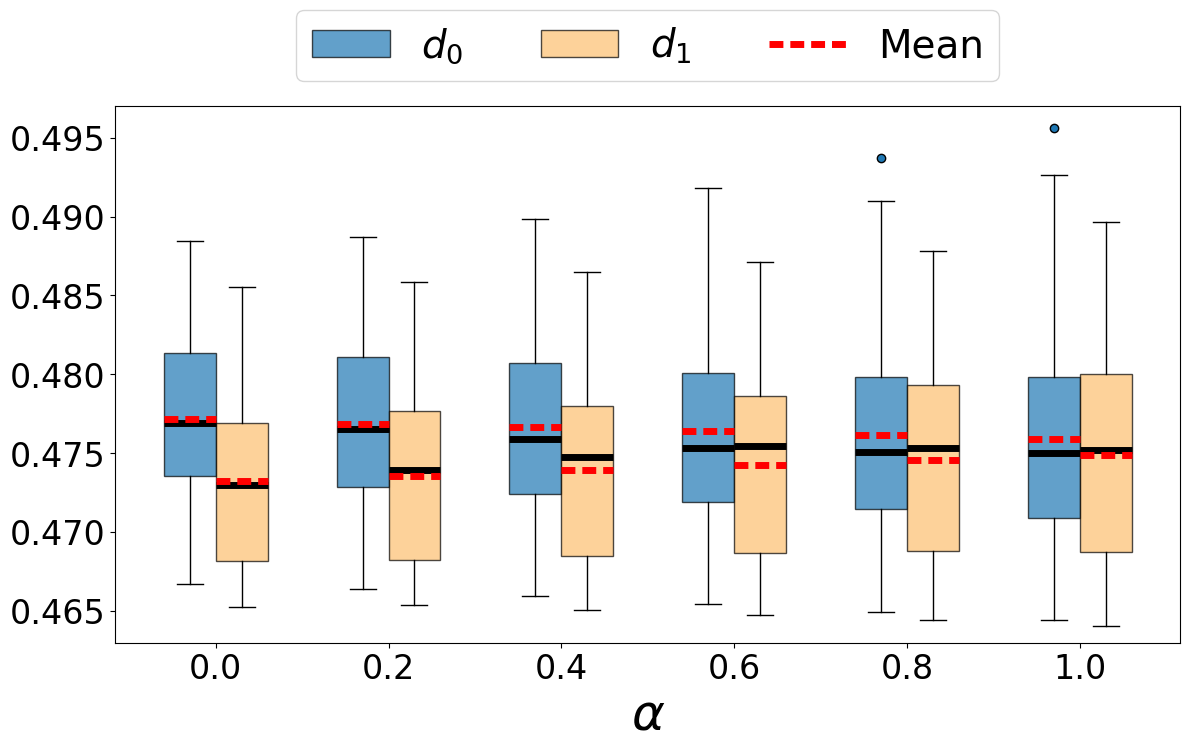

In [49]:
plot_grouped_boxplot(d0_efo_ex_ante, d1_efo_ex_ante, mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_EFO.pdf"), price=False, y_limits=[0.463, 0.497])
plot_grouped_boxplot(d0_feo_ex_ante, d1_feo_ex_ante, mean_plot=True, filename=os.path.join(dir, f"Parity_ExAnte_Demand_FEO.pdf"), price=False, y_limits=[0.463, 0.497])

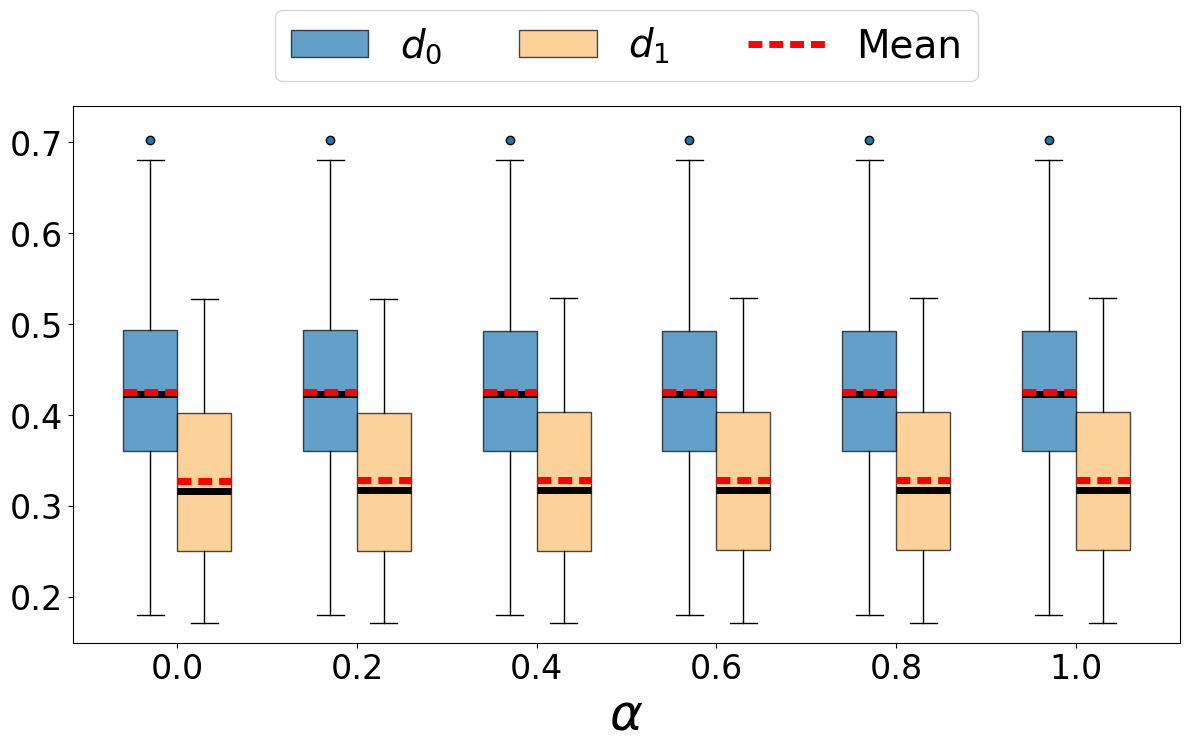

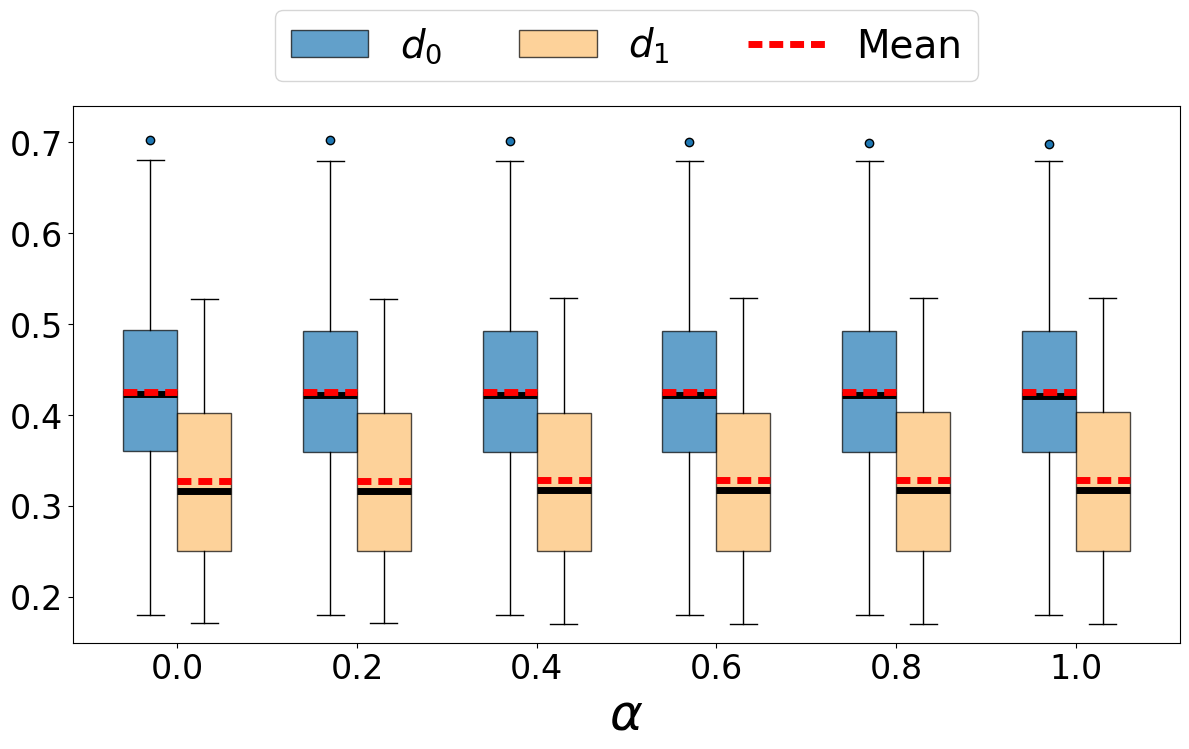

In [53]:
plot_grouped_boxplot(d0_efo_ex_post, d1_efo_ex_post, mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_EFO.pdf"), price=False, y_limits=[0.15, 0.74])
plot_grouped_boxplot(d0_feo_ex_post, d1_feo_ex_post, mean_plot=True, filename=os.path.join(dir, f"Parity_ExPost_Demand_FEO.pdf"), price=False, y_limits=[0.15, 0.74])

In [54]:
wel_feo_test = [rev_feo_test[i] + sur_feo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_feo_test)
sur_norm = normalize_to_percentage(sur_feo_test)
wel_norm = normalize_to_percentage(wel_feo_test)

target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
indices = [target_alphas.index(a) for a in target_alphas]

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0     0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0  100.03  100.04  100.07  100.09  100.11
S(α)/S(0)  100.0   99.97   99.95   99.92   99.89   99.87
W(α)/W(0)  100.0   99.99   99.99   99.98   99.98   99.97
--------------------------------------------------


In [55]:
wel_efo_test = [rev_efo_test[i] + sur_efo_test[i] for i in range(len(beta_list))]
rev_norm = normalize_to_percentage(rev_efo_test)
sur_norm = normalize_to_percentage(sur_efo_test)
wel_norm = normalize_to_percentage(wel_efo_test)

data = {
    'α': target_alphas,
    'R(α)/R(0)': [rev_norm[i] for i in indices],
    'S(α)/S(0)': [sur_norm[i] for i in indices],
    'W(α)/W(0)': [wel_norm[i] for i in indices]
}

df = pd.DataFrame(data).set_index('α').T

print("Table: Normalized Performance Measures (%)")
print("-" * 50)
print(df.round(2))
print("-" * 50)

Table: Normalized Performance Measures (%)
--------------------------------------------------
α            0.0    0.2     0.4     0.6     0.8     1.0
R(α)/R(0)  100.0  100.0  100.00  100.01  100.01  100.01
S(α)/S(0)  100.0  100.0   99.99   99.99   99.99   99.99
W(α)/W(0)  100.0  100.0  100.00  100.00  100.00  100.00
--------------------------------------------------
